In [12]:
# Cell 0 — Mount Google Drive and extract dataset
# ── Step 1: Run on your LOCAL machine ──
# cd /Users/BAEK/Code/gaitkeeper
# zip -r data_processed.zip data_processed/
#
# ── Step 2: Upload data_processed.zip to MyDrive/Colab/ in Google Drive ──
# ── Step 3: Run cells top to bottom ──

from google.colab import drive
import zipfile, os

drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/Colab/data_processed.zip'

if not os.path.exists('/content/data_processed'):
    print('Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/')
    print('Done.')
else:
    print('Dataset already extracted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.


In [13]:
# Cell 1 — Installs
!pip install ultralytics kornia --quiet

In [14]:
# Cell 2 — Imports
import cv2
import random
import numpy as np
import torch
import torch.nn.functional as F
import kornia
import kornia.augmentation as K
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

In [15]:
# Cell 3 — Config
# ── Training ──────────────────────────────────────────
PATCH_H          = 200    # patch height in pixels
PATCH_W          = 150    # patch width in pixels
PATCH_SCALE      = 0.5    # fraction of person bbox width
SHIRT_TOP        = 0.20   # top of shirt as fraction of person bbox height
SHIRT_BOT        = 0.60   # bottom of shirt as fraction of person bbox height
EPSILON          = 0.6    # max pixel delta — increased from V4's 0.4 for more perturbation budget
LR               = 0.005
NUM_STEPS        = 800
EOT_N            = 6      # augmentations per step — all on the SAME sampled image
TOP_K            = 30     # top-K anchors for misclassification loss

# ── Loss weights ──────────────────────────────────────
# V5: targeted misclassification replaces plain conf suppression
# TARGET_CLASS: COCO class index to push anchors toward (0=person, skip)
# 32=sports ball, 26=handbag, 24=backpack — pick something visually unlike a person
TARGET_CLASS     = 32     # sports ball
MISCLASS_LOSS_W  = 0.7    # suppress person + push toward TARGET_CLASS
MASK_LOSS_W      = 0.3    # mask suppression (already near-perfect in V4)

# ── Curriculum ────────────────────────────────────────
CURRICULUM_STEPS = 200    # steps on eval image before switching to multi-image

# ── Dataset ────────────────────────────────────────────
USE_CACHED_SAMPLES = True   # True → load pkl from Drive; False → re-extract from videos

# ── Paths ──────────────────────────────────────────────
DRIVE_DIR        = '/content/drive/MyDrive/Colab'
IMAGE_PATH       = f'{DRIVE_DIR}/person.jpg'
VIDEO_DIR        = '/content/data_processed'
FRAMES_PER_VIDEO = 10
SAMPLES_PATH     = f'{DRIVE_DIR}/training_samples.pkl'

# ── Model ──────────────────────────────────────────────
YOLO_MODEL = 'yolov8n-seg'
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


In [16]:
# Cell 4 — Load YOLOv8-seg, freeze weights
yolo = YOLO(YOLO_MODEL)
torch_model = yolo.model.to(DEVICE)
torch_model.eval()

for p in torch_model.parameters():
    p.requires_grad_(False)

print(f'Model loaded: {YOLO_MODEL} | Parameters frozen: {sum(p.numel() for p in torch_model.parameters()):,}')

Model loaded: yolov8n-seg | Parameters frozen: 3,409,968


In [17]:
# Cell 5 — Forward pass helpers
def yolo_raw_forward(img_tensor):
    out = torch_model(img_tensor)
    return {'preds': out[0][0], 'proto': out[0][1]}

def img_to_tensor(img_np):
    """uint8 HxWx3 BGR numpy → [1, 3, 640, 640] float32 tensor on DEVICE"""
    img = cv2.resize(img_np, (640, 640))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    return t.unsqueeze(0).to(DEVICE)

In [18]:
# Cell 6 — Shirt detection and patch placement
def detect_shirt_region(img_np):
    """
    Returns (shirt_box_img, shirt_box_mask) in 640x640 and 160x160 coords.
    Returns (None, None) if no person detected.
    """
    with torch.no_grad():
        results = yolo(cv2.resize(img_np, (640, 640)), verbose=False)

    if not results or results[0].boxes is None or len(results[0].boxes) == 0:
        return None, None

    boxes = results[0].boxes
    person_mask = (boxes.cls == 0)
    if not person_mask.any():
        return None, None

    best_idx = boxes.conf[person_mask].argmax()
    x1, y1, x2, y2 = boxes.xyxy[person_mask][best_idx].cpu().numpy()

    h, w = y2 - y1, x2 - x1
    cx = (x1 + x2) / 2
    half_w = w * PATCH_SCALE / 2
    sx1 = int(cx - half_w)
    sy1 = int(y1 + h * SHIRT_TOP)
    sx2 = int(cx + half_w)
    sy2 = int(y1 + h * SHIRT_BOT)

    scale = 160 / 640
    mx1 = max(0, int(sx1 * scale))
    my1 = max(0, int(sy1 * scale))
    mx2 = min(159, int(sx2 * scale))
    my2 = min(159, int(sy2 * scale))

    if mx2 <= mx1 or my2 <= my1:
        return None, None

    return (sx1, sy1, sx2, sy2), (mx1, my1, mx2, my2)


def paste_patch(img_tensor, patch, shirt_box):
    """Paste patch into img_tensor at shirt_box, preserving gradient through patch."""
    x1, y1, x2, y2 = [int(v) for v in shirt_box]
    w, h = x2 - x1, y2 - y1
    if w <= 0 or h <= 0:
        return img_tensor
    patch_resized = F.interpolate(patch, size=(h, w), mode='bilinear', align_corners=False)
    patched = img_tensor.clone()
    patched[:, :, y1:y2, x1:x2] = patch_resized
    return patched

In [19]:
# Cell 7 — Loss functions
#
# V5 changes:
#   1. Targeted misclassification: top-K anchors are pushed toward TARGET_CLASS
#      (sports ball, class 32), not just suppressed. Gives optimizer a concrete target.
#   2. Stride-aware anchor selection: prefer stride-16/32 anchors (coarse grid)
#      which are the ones that actually fire for full-body person detection.
#      Fine-grid (stride-8) anchors only see a small patch of the shirt and are
#      not the dominant anchors for the final YOLO detection.

def build_anchor_grid():
    """Pre-build YOLOv8 anchor center coords and strides once."""
    strides, grids = [8, 16, 32], [80, 40, 20]
    cx_list, cy_list, stride_list = [], [], []
    for stride, g in zip(strides, grids):
        xs = (torch.arange(g, device=DEVICE) + 0.5) * stride
        ys = (torch.arange(g, device=DEVICE) + 0.5) * stride
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')
        cx_list.append(xx.reshape(-1))
        cy_list.append(yy.reshape(-1))
        stride_list.append(torch.full((g * g,), stride, device=DEVICE))
    return (torch.cat(cx_list),
            torch.cat(cy_list),
            torch.cat(stride_list))   # all [8400]

ANCHOR_CX, ANCHOR_CY, ANCHOR_STRIDE = build_anchor_grid()

# Coarse-grid mask: stride 16 + stride 32 = anchors that dominate person detection
COARSE_MASK = (ANCHOR_STRIDE >= 16)   # [8400] bool, 2000 True entries


def misclassification_loss(raw, patch_box_img=None):
    """
    V5 targeted misclassification loss:
      - Identify TOP_K highest person-conf anchors among coarse-grid anchors
        (stride ≥ 16) — these dominate the final YOLO person detection.
      - Minimize their person class score (push detection confidence down).
      - Simultaneously maximize TARGET_CLASS score at those same anchors
        (give the optimizer a concrete direction instead of just "less person").
    """
    preds = raw['preds']                          # [1, 116, 8400]
    # Class logits: indices 4..83 = classes 0..79
    person_logits = preds[0, 4, :]                # class 0 (person)
    target_logits = preds[0, 4 + TARGET_CLASS, :] # e.g. class 32 (sports ball)

    person_conf = torch.sigmoid(person_logits)
    target_conf = torch.sigmoid(target_logits)

    # Focus on coarse-grid anchors (the dominant detection anchors for full bodies)
    coarse_person = person_conf[COARSE_MASK]      # [2000]
    coarse_target = target_conf[COARSE_MASK]      # [2000]

    # Top-K highest person-confidence coarse anchors
    topk_idx = coarse_person.topk(TOP_K, largest=True).indices

    suppress = coarse_person[topk_idx].mean()     # push this down → 0
    promote  = coarse_target[topk_idx].mean()     # push this up  → 1

    # Combined: minimize (suppress - promote) which = minimize person + maximize target
    return suppress - promote


def mask_suppression_loss(raw, patch_box_mask):
    """Minimize mask probability in the patch region for the best-detected person."""
    preds = raw['preds']
    proto = raw['proto']

    person_conf = torch.sigmoid(preds[0, 4, :])
    best        = person_conf.argmax()

    if person_conf[best].item() < 0.05:
        return preds[0, 84:, 0].sum() * 0.0

    mask_coeff  = preds[0, 84:, best]
    proto_flat  = proto[0].reshape(32, -1)
    mask_logits = (mask_coeff @ proto_flat).reshape(160, 160)
    mask_prob   = torch.sigmoid(mask_logits)

    x1, y1, x2, y2 = patch_box_mask
    patch_region = mask_prob[y1:y2, x1:x2]

    if patch_region.numel() == 0:
        return preds[0, 84:, 0].sum() * 0.0

    return patch_region.mean()


def combined_loss(raw, patch_box_img, patch_box_mask):
    m_loss = misclassification_loss(raw, patch_box_img)
    s_loss = mask_suppression_loss(raw, patch_box_mask)
    return MISCLASS_LOSS_W * m_loss + MASK_LOSS_W * s_loss

In [20]:
# Cell 8 — Differentiable EoT transforms via kornia
def apply_eot_transforms(patch):
    """patch: [1, 3, H, W] — returns augmented patch, gradient preserved."""
    p = patch

    if random.random() < 0.5:
        p = (p * random.uniform(0.6, 1.4)).clamp(0, 1)

    if random.random() < 0.5:
        p = K.ColorJitter(hue=0.1, saturation=0.1, p=1.0)(p)

    if random.random() < 0.5:
        angle = torch.tensor([random.uniform(-15, 15)], device=DEVICE)
        p = kornia.geometry.rotate(p, angle)

    if random.random() < 0.5:
        p = K.RandomPerspective(distortion_scale=0.2, p=1.0)(p)

    if random.random() < 0.5:
        ksize = random.choice([3, 5, 7])
        p = kornia.filters.motion_blur(p, kernel_size=ksize,
                                       angle=random.uniform(0, 360), direction=0.0)

    if random.random() < 0.5:
        p = p + torch.randn_like(p) * random.uniform(0, 10) / 255.0

    return p.clamp(0, 1)

In [21]:
# Cell 9 — Load or build training dataset
import pickle
from glob import glob

if USE_CACHED_SAMPLES:
    with open(SAMPLES_PATH, 'rb') as f:
        training_samples = pickle.load(f)
    print(f'Loaded {len(training_samples)} samples from {SAMPLES_PATH}')
else:
    def sample_frames_from_video(video_path, n_frames):
        cap = cv2.VideoCapture(video_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release()
            return []
        indices = [int(i * total / n_frames) for i in range(n_frames)]
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frames.append(frame)
        cap.release()
        return frames

    video_paths = glob(f'{VIDEO_DIR}/**/*.mp4', recursive=True)
    print(f'Found {len(video_paths)} videos. Extracting frames...')

    training_samples = []
    for vp in sorted(video_paths):
        frames = sample_frames_from_video(vp, FRAMES_PER_VIDEO)
        valid = 0
        for frame in frames:
            b_img, b_mask = detect_shirt_region(frame)
            if b_img is not None:
                training_samples.append((frame, b_img, b_mask))
                valid += 1
        print(f'  {Path(vp).name}: {valid}/{len(frames)} frames detected')

    with open(SAMPLES_PATH, 'wb') as f:
        pickle.dump(training_samples, f)
    print(f'\nSaved {len(training_samples)} samples to {SAMPLES_PATH}')

print(f'Total training samples: {len(training_samples)}')

Loaded 280 samples from /content/drive/MyDrive/Colab/training_samples.pkl
Total training samples: 280


In [22]:
# Cell 10 — Initialize patch + baseline
img_eval = cv2.imread(IMAGE_PATH)
if img_eval is None:
    raise FileNotFoundError(f'Could not load {IMAGE_PATH}')

with torch.no_grad():
    raw_baseline = yolo_raw_forward(img_to_tensor(img_eval))
    box_eval_img, box_eval_mask = detect_shirt_region(img_eval)
    baseline_conf = torch.sigmoid(raw_baseline['preds'][0, 4, :])[COARSE_MASK].topk(TOP_K).values.mean().item()

print(f'Baseline person conf in patch region: {baseline_conf:.4f}')

torch.manual_seed(42)
patch = torch.empty(1, 3, PATCH_H, PATCH_W, device=DEVICE).uniform_(0.4, 0.6)
patch.requires_grad_(True)
patch_init = patch.data.clone()

optimizer = torch.optim.Adam([patch], lr=LR)
print(f'Patch initialized: {list(patch.shape)}')

Baseline person conf in patch region: 0.5685
Patch initialized: [1, 3, 200, 150]


In [23]:
# Cell 11 — Training loop (V4: curriculum + global top-K loss)
#
# Phase 1 (steps 0 → CURRICULUM_STEPS-1):
#   Train exclusively on person.jpg to find a strong adversarial direction first.
#   This prevents early steps from getting torn between 280 conflicting gradients.
#
# Phase 2 (steps CURRICULUM_STEPS → NUM_STEPS-1):
#   Switch to random sampling from all 280 training frames for generalization.

if not training_samples:
    raise RuntimeError('No training samples — run Cell 9 first')

# Build a 1-element list for curriculum phase
eval_sample = (img_eval, box_eval_img, box_eval_mask)

loss_history      = []
phase_switch_step = None

for step in range(NUM_STEPS):
    optimizer.zero_grad()

    # Curriculum: Phase 1 uses eval image; Phase 2 uses full dataset
    if step < CURRICULUM_STEPS:
        img, box_img, box_mask = eval_sample
    else:
        if phase_switch_step is None:
            phase_switch_step = step
            print(f'Step {step}: switching to multi-image training ({len(training_samples)} samples)')
        img, box_img, box_mask = random.choice(training_samples)

    img_tensor = img_to_tensor(img)   # fixed for all EOT iters this step

    step_loss = 0.0
    for _ in range(EOT_N):
        aug_patch = apply_eot_transforms(patch)
        patched   = paste_patch(img_tensor, aug_patch, box_img)
        raw       = yolo_raw_forward(patched)
        loss      = combined_loss(raw, box_img, box_mask) / EOT_N
        loss.backward()
        step_loss += loss.item()

    optimizer.step()

    with torch.no_grad():
        delta = (patch.data - patch_init).clamp(-EPSILON, EPSILON)
        patch.data = (patch_init + delta).clamp(0, 1)

    loss_history.append(step_loss)

    if step % 50 == 0:
        phase = 'curriculum' if step < CURRICULUM_STEPS else 'multi-img'
        print(f'Step {step:3d}/{NUM_STEPS} | loss {step_loss:.4f} | {phase}')

print('Training complete.')

Step   0/800 | loss 0.2088 | curriculum
Step  50/800 | loss 0.0522 | curriculum
Step 100/800 | loss 0.0533 | curriculum
Step 150/800 | loss 0.0437 | curriculum
Step 200: switching to multi-image training (280 samples)
Step 200/800 | loss 0.2014 | multi-img
Step 250/800 | loss 0.3102 | multi-img
Step 300/800 | loss 0.0602 | multi-img
Step 350/800 | loss 0.0699 | multi-img
Step 400/800 | loss 0.0687 | multi-img
Step 450/800 | loss 0.1747 | multi-img
Step 500/800 | loss 0.0705 | multi-img
Step 550/800 | loss 0.0488 | multi-img
Step 600/800 | loss 0.1716 | multi-img
Step 650/800 | loss 0.0549 | multi-img
Step 700/800 | loss 0.1118 | multi-img
Step 750/800 | loss 0.0617 | multi-img
Training complete.


In [24]:
# Cell 12 — Evaluation metrics
img_eval       = cv2.imread(IMAGE_PATH)
img_eval_640   = cv2.resize(img_eval, (640, 640))
img_tensor_eval = img_to_tensor(img_eval)
box_eval_img, box_eval_mask = detect_shirt_region(img_eval)

patch_np = patch.detach().cpu().squeeze().permute(1, 2, 0).numpy()
patch_np = (patch_np * 255).astype(np.uint8)

x1, y1, x2, y2 = box_eval_img
img_patched_np = img_eval_640.copy()
img_patched_np[y1:y2, x1:x2] = cv2.cvtColor(
    cv2.resize(patch_np, (x2 - x1, y2 - y1)), cv2.COLOR_RGB2BGR
)

with torch.no_grad():
    raw_clean   = yolo_raw_forward(img_tensor_eval)
    patched_t   = paste_patch(img_tensor_eval, patch, box_eval_img)
    raw_patched = yolo_raw_forward(patched_t)

    clean_mclass  = misclassification_loss(raw_clean).item()
    patched_mclass = misclassification_loss(raw_patched).item()
    clean_mask    = mask_suppression_loss(raw_clean,   box_eval_mask).item()
    patched_mask  = mask_suppression_loss(raw_patched, box_eval_mask).item()

    # Raw person conf metric (top-K coarse anchors) for comparison with V4
    clean_person_conf   = torch.sigmoid(raw_clean['preds'][0, 4, :])[COARSE_MASK].topk(TOP_K).values.mean().item()
    patched_person_conf = torch.sigmoid(raw_patched['preds'][0, 4, :])[COARSE_MASK].topk(TOP_K).values.mean().item()

# YOLO high-level detection confidence (what the model actually reports)
results_clean_eval   = yolo(img_eval_640,     verbose=False)
results_patched_eval = yolo(img_patched_np,   verbose=False)

def best_person_conf(results):
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None
    mask = (boxes.cls == 0)
    if not mask.any():
        return None
    return boxes.conf[mask].max().item()

yolo_clean   = best_person_conf(results_clean_eval)
yolo_patched = best_person_conf(results_patched_eval)

conf_drop  = (clean_person_conf - patched_person_conf) / (clean_person_conf + 1e-9) * 100
mask_drop  = (clean_mask - patched_mask) / (clean_mask + 1e-9) * 100

print('─' * 56)
print(f'{"Metric":<36} {"Clean":>7}  {"Patched":>8}')
print('─' * 56)
print(f'{"Misclass loss (suppress−promote)":<36} {clean_mclass:>7.4f}  {patched_mclass:>8.4f}')
print(f'{"Person conf — coarse top-K":<36} {clean_person_conf:>7.4f}  {patched_person_conf:>8.4f}  ({conf_drop:+.1f}%)')
print(f'{"Mask prob in patch region":<36} {clean_mask:>7.4f}  {patched_mask:>8.4f}  ({mask_drop:+.1f}%)')
if yolo_clean is not None:
    yolo_drop = (yolo_clean - (yolo_patched or 0)) / yolo_clean * 100
    patched_str = f'{yolo_patched:.4f}' if yolo_patched else 'N/A (no detection)'
    print(f'{"YOLO detection conf (high-level)":<36} {yolo_clean:>7.4f}  {patched_str:>8}  ({yolo_drop:+.1f}%)')
else:
    print(f'{"YOLO detection conf (high-level)":<36} {"N/A":>7}')
print('─' * 56)

────────────────────────────────────────────────────────
Metric                                 Clean   Patched
────────────────────────────────────────────────────────
Misclass loss (suppress−promote)      0.0685    0.0656
Person conf — coarse top-K            0.5685    0.5656  (+0.5%)
Mask prob in patch region             0.9980    0.0123  (+98.8%)
YOLO detection conf (high-level)      0.9038    0.7442  (+17.7%)
────────────────────────────────────────────────────────


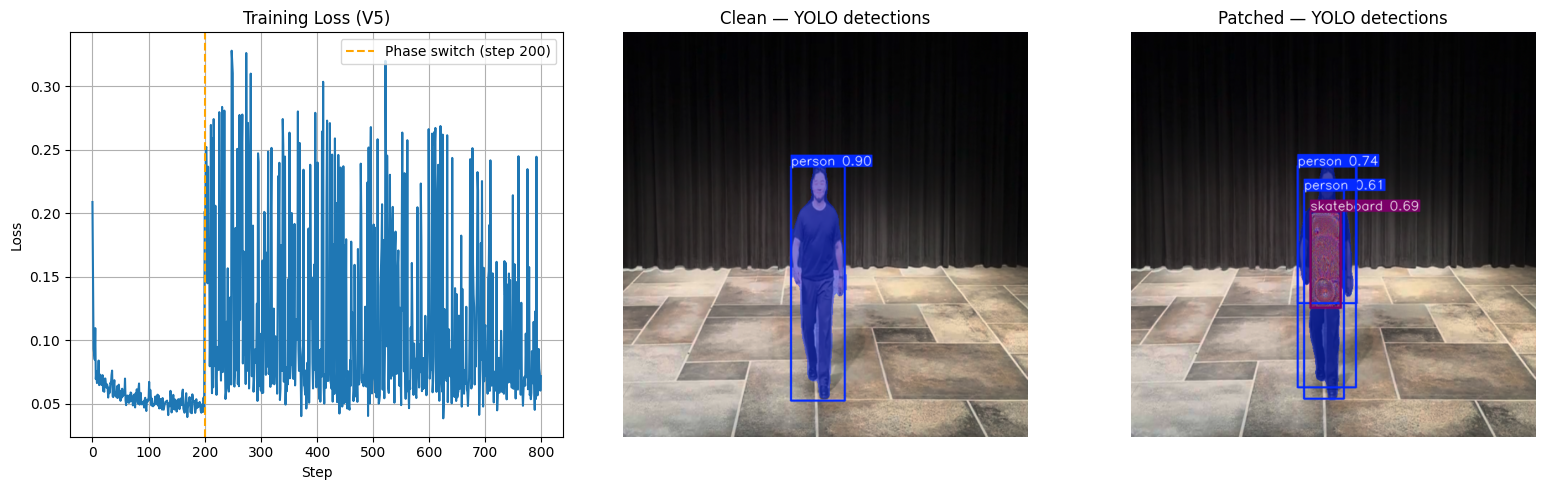

In [25]:
# Cell 13 — Visual evaluation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(loss_history)
if CURRICULUM_STEPS > 0:
    axes[0].axvline(x=CURRICULUM_STEPS, color='orange', linestyle='--',
                    label=f'Phase switch (step {CURRICULUM_STEPS})')
    axes[0].legend()
axes[0].set_title('Training Loss (V5)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].imshow(cv2.cvtColor(results_clean_eval[0].plot(), cv2.COLOR_BGR2RGB))
axes[1].set_title('Clean — YOLO detections')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(results_patched_eval[0].plot(), cv2.COLOR_BGR2RGB))
axes[2].set_title('Patched — YOLO detections')
axes[2].axis('off')

plt.tight_layout()
plt.show()